## Notebook11

### Setup

Run all of the following before starting the notebook.

In [4]:
! wget -q -nc https://raw.githubusercontent.com/taylor-arnold/fds2/refs/heads/main/funs.py

In [5]:
import polars as pl
from plotnine import ggplot, aes
from polars import col as c

import funs

ub = "https://raw.githubusercontent.com/taylor-arnold/fds2/refs/heads/main/"

In [6]:
us_pop = (
    pl.read_csv(ub + "data/us_city_population.csv")
    .select(c.city, c.state, c.year, c.population, c.lon, c.lat)
    .filter(c.population.null_count().over(c.city) <= 1)
)

### Questions

This is the same table as last week: 289 American cities, one row per city per
census from 1790 to 2010, with the population in thousands. A city that did not
exist yet has a population of 0. The columns `lon` and `lat` give the location of
each city.

Today is a review for the exam on Wednesday. The questions go back over plots,
grouping, and window functions from the last few weeks, one step at a time.

Unless a question says otherwise, just print the result of each block; do not save
it to a variable.

1. Filter the data to the 2010 census and draw a scatterplot with longitude on the
x-axis and latitude on the y-axis.

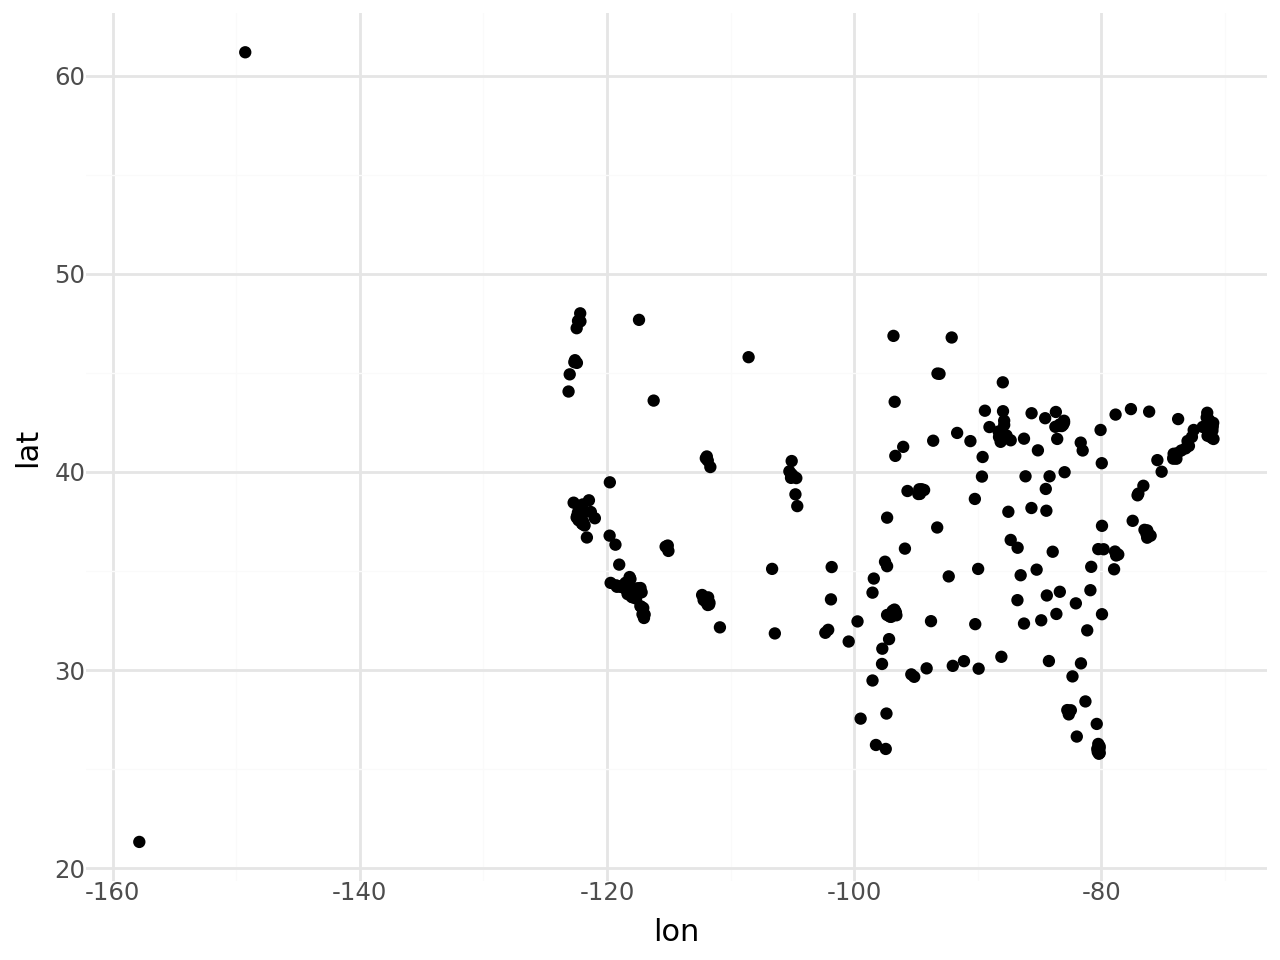

In [7]:
(
    us_pop
    .filter(c.year == 2010)
    .ggplot(aes(c.lon, c.lat))
    .geom_point()
)

2. Draw the same plot, but make all of the points red.

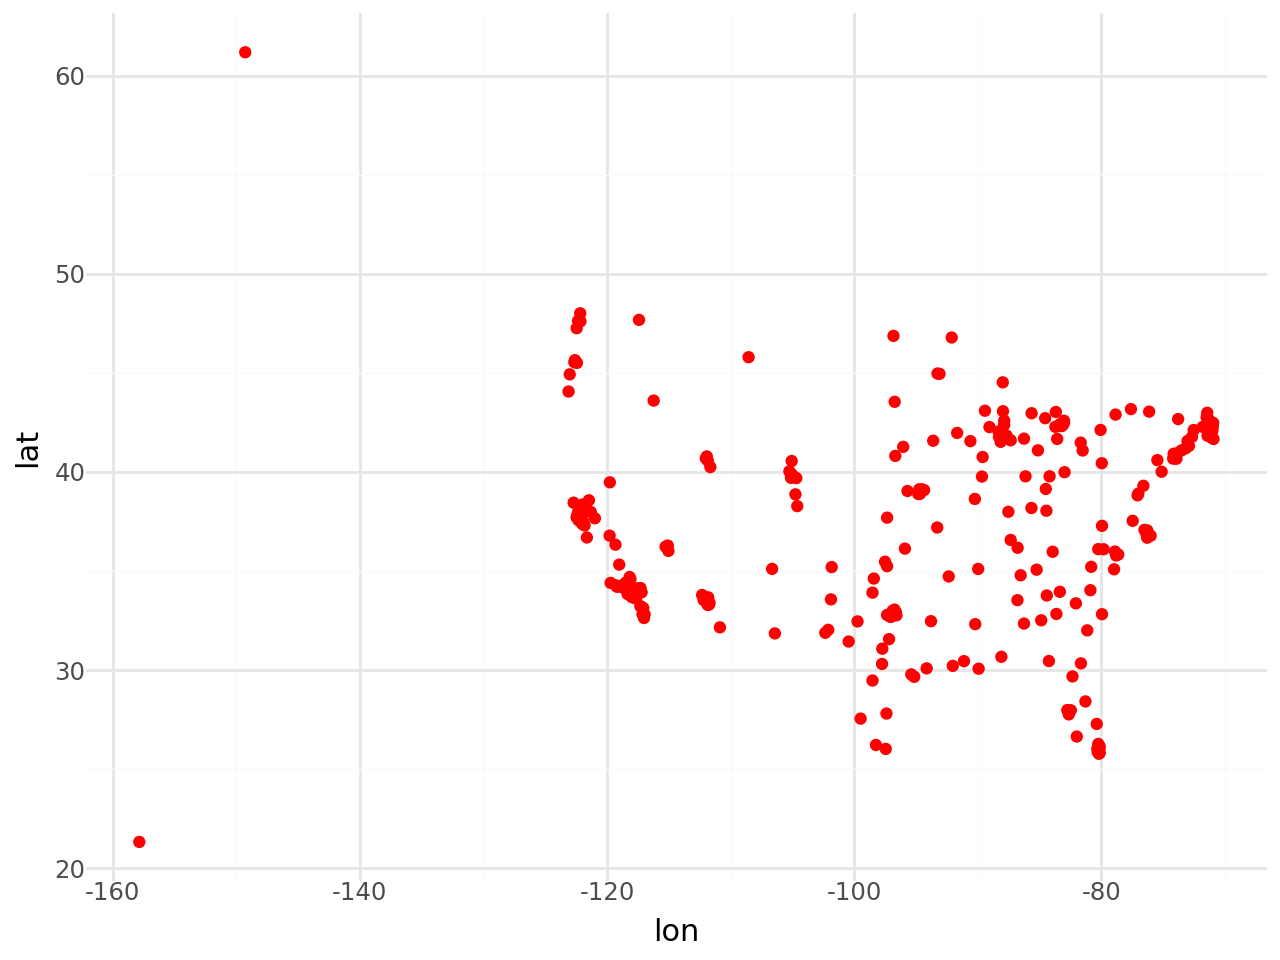

In [8]:
(
    us_pop
    .filter(c.year == 2010)
    .ggplot(aes(c.lon, c.lat))
    .geom_point(color="red")
)

The color is fixed, so it goes inside `geom_point` but outside of `aes`.

3. Draw the same plot again, but now make the size of each point show the city's
population.

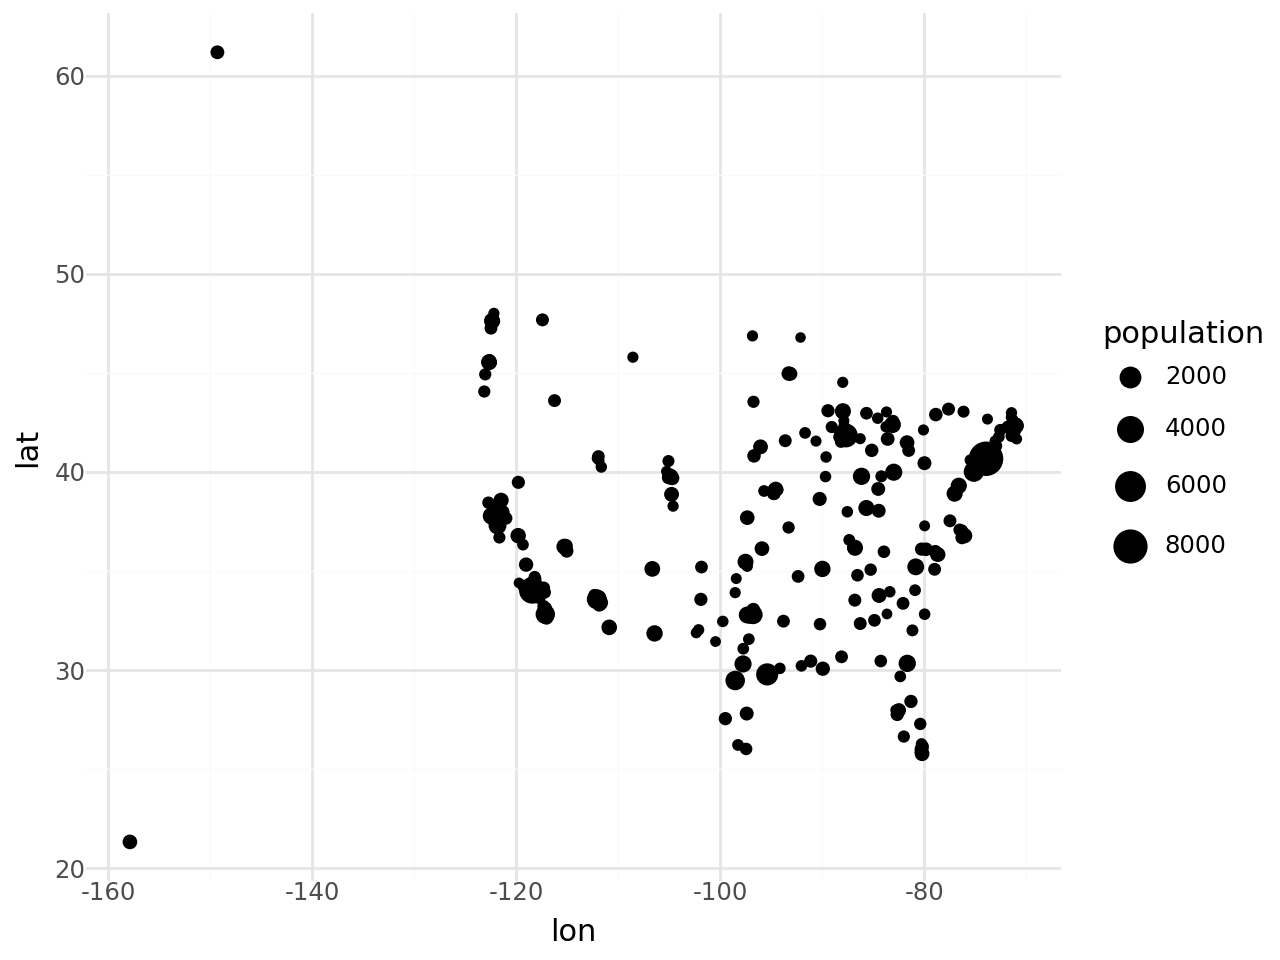

In [9]:
(
    us_pop
    .filter(c.year == 2010)
    .ggplot(aes(c.lon, c.lat, size=c.population))
    .geom_point()
)

The size now comes from a column, so it goes inside `aes`.

4. Filter to the 2010 cities in Virginia (`"VA"`) and draw a text plot with longitude
on the x-axis, latitude on the y-axis, and the city name as the label.

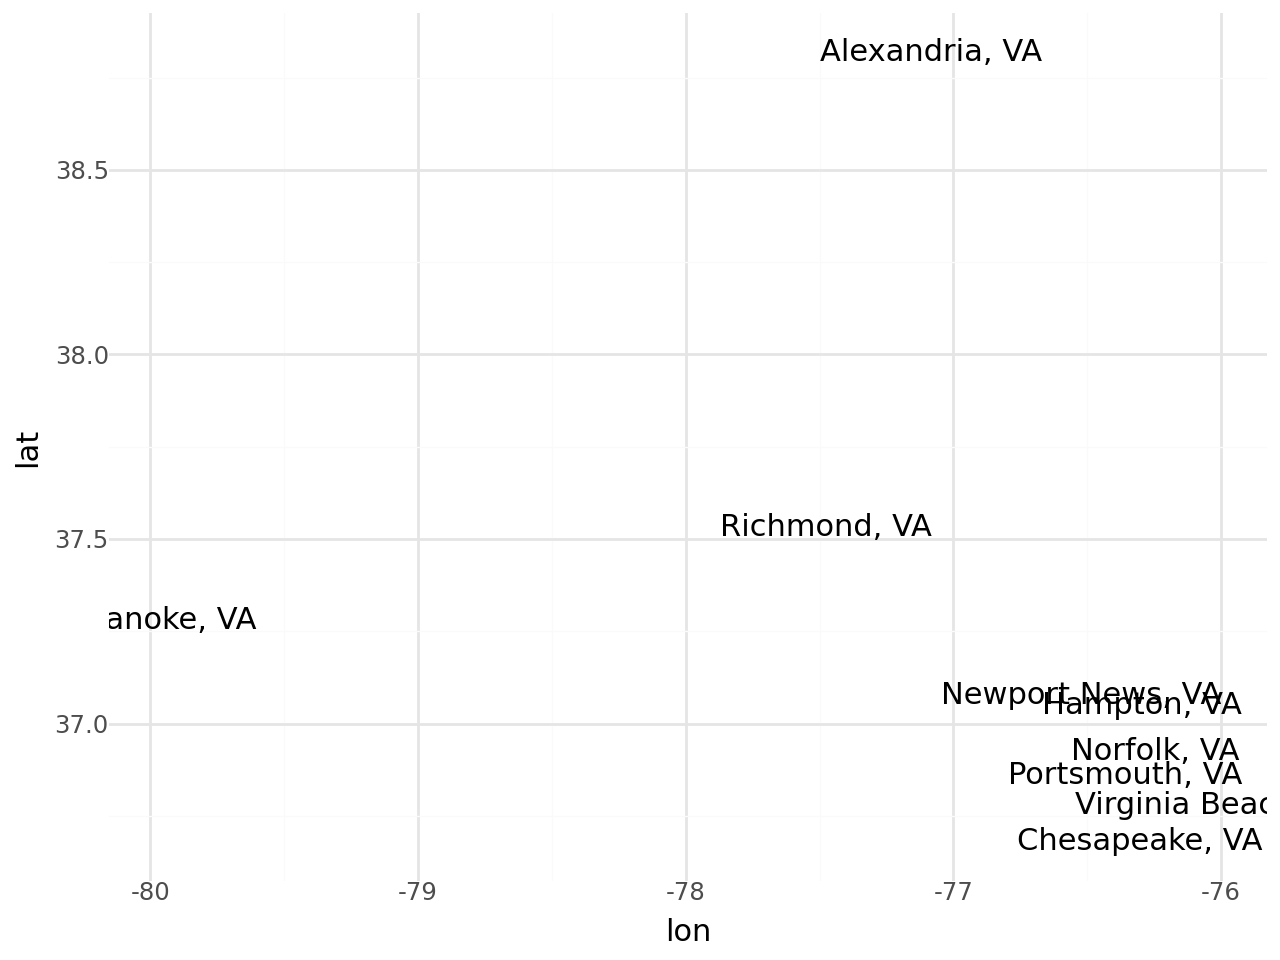

In [10]:
(
    us_pop
    .filter(c.year == 2010, c.state == "VA")
    .ggplot(aes(c.lon, c.lat, label=c.city))
    .geom_text()
)

5. Filter to Richmond (`"Richmond, VA"`) and draw a line plot of its population
against the year.

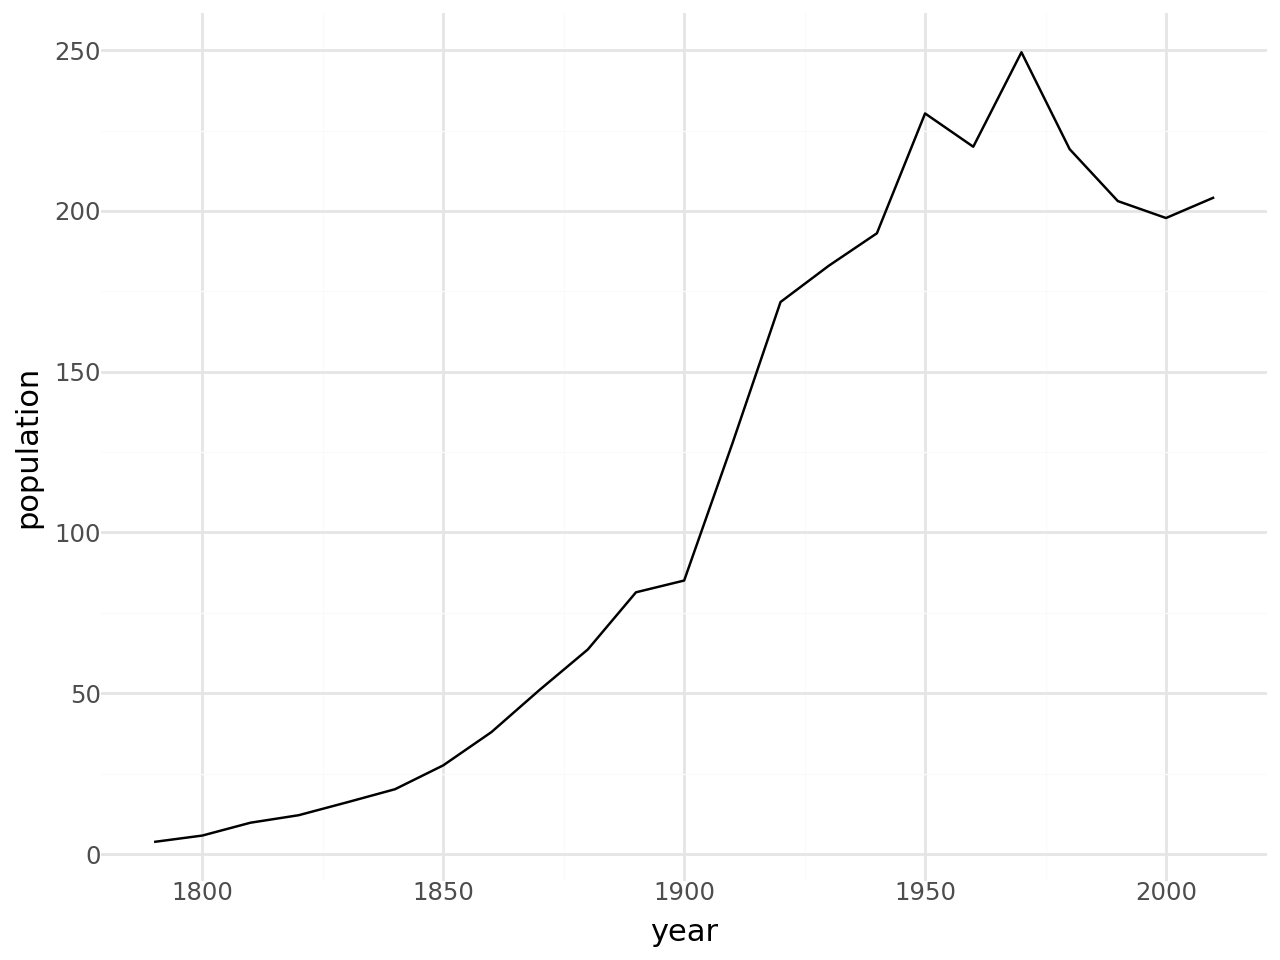

In [11]:
(
    us_pop
    .filter(c.city == "Richmond, VA")
    .ggplot(aes(c.year, c.population))
    .geom_line()
)

6. Summarize the whole dataset in a single row. Give the number of rows with
`pl.len()`, the number of different cities with `c.city.n_unique()`, and the number
of different states with `c.state.n_unique()`.

In [12]:
(
    us_pop
    .select(
        n = pl.len(),
        n_cities = c.city.n_unique(),
        n_states = c.state.n_unique()
    )
)

n,n_cities,n_states
u32,u32,u32
6647,289,46


There are 6,647 rows but only 289 cities, because each city appears once for every
census. We use `.select` here because `.agg` only works after a `.group_by`.

7. For the 2010 census, group by state and compute the total population of the
cities in each state.

In [13]:
(
    us_pop
    .filter(c.year == 2010)
    .group_by(c.state)
    .agg(total = c.population.sum())
)

state,total
str,f64
"""LA""",893.256
"""NH""",196.059
"""NE""",667.337
"""HI""",387.17
"""KS""",954.871
…,…
"""TX""",10719.818
"""OR""",1000.192
"""NC""",2198.727


8. Take the code from the previous question and draw it as a bar plot with
`geom_col`, with the state on the x-axis and the total on the y-axis. Add
`coord_flip()` so the bars run horizontally.

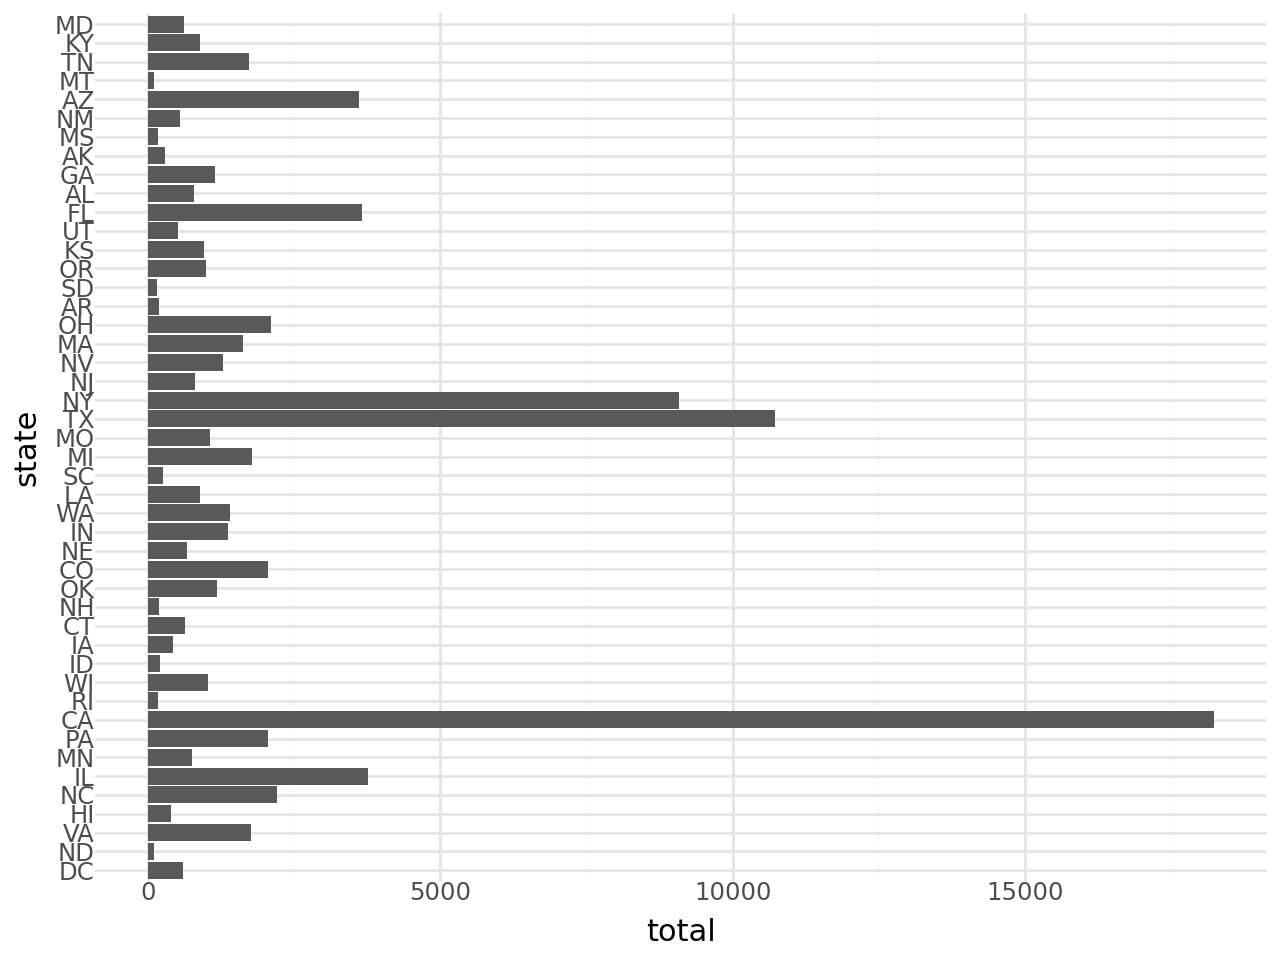

In [14]:
(
    us_pop
    .filter(c.year == 2010)
    .group_by(c.state)
    .agg(total = c.population.sum())
    .ggplot(aes(c.state, c.total))
    .geom_col()
    .coord_flip()
)

California, Texas, and New York have the longest bars.

9. Group by year and count the number of cities with a population above zero in each
census. Use `(c.population > 0).sum()` inside of `.agg`. Sort by year.

In [15]:
(
    us_pop
    .group_by(c.year)
    .agg(n_cities = (c.population > 0).sum())
    .sort(c.year)
)

year,n_cities
i64,u32
1790,16
1800,22
1810,27
1820,31
1830,43
…,…
1970,285
1980,289
1990,289


Only 16 of the cities had any population in 1790. By 1900 there were 216.

10. Take the code from the previous question and draw it as a line plot against the
year.

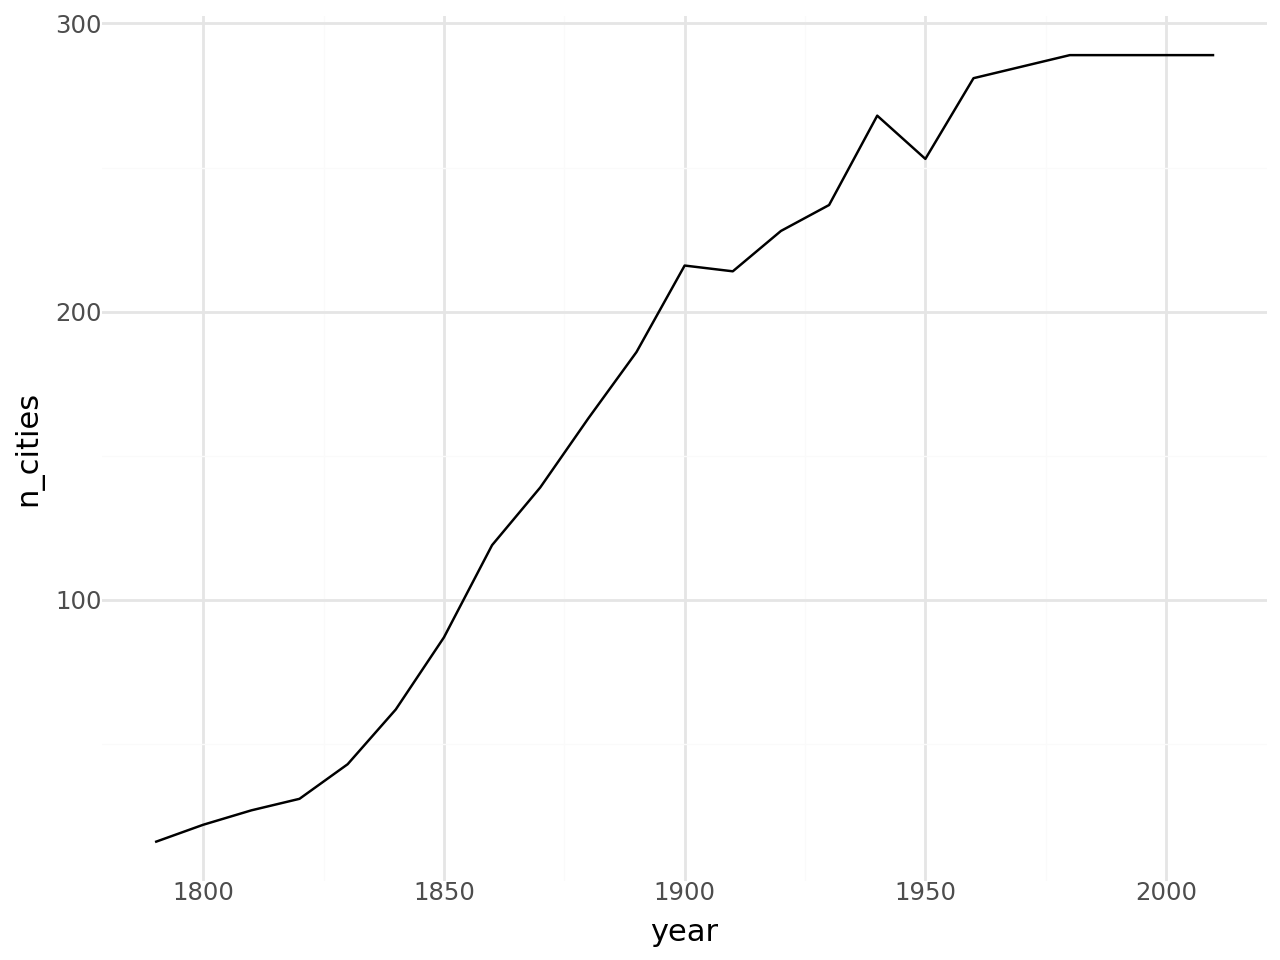

In [16]:
(
    us_pop
    .group_by(c.year)
    .agg(n_cities = (c.population > 0).sum())
    .sort(c.year)
    .ggplot(aes(c.year, c.n_cities))
    .geom_line()
)

11. Filter to three states, California, Texas, and New York, using
`c.state.is_in(["CA", "TX", "NY"])`. Then group by both state and year and compute
the total population.

In [17]:
(
    us_pop
    .filter(c.state.is_in(["CA", "TX", "NY"]))
    .group_by(c.state, c.year)
    .agg(total = c.population.sum())
)

state,year,total
str,i64,f64
"""CA""",1790,0.0
"""CA""",1800,0.0
"""TX""",1800,0.0
"""NY""",1810,108.635
"""CA""",1820,0.0
…,…,…
"""NY""",1990,8335.347
"""TX""",1990,7860.672
"""CA""",2010,18231.904


12. Take the code from the previous question and draw a line plot of the total
against the year, with one color for each state.

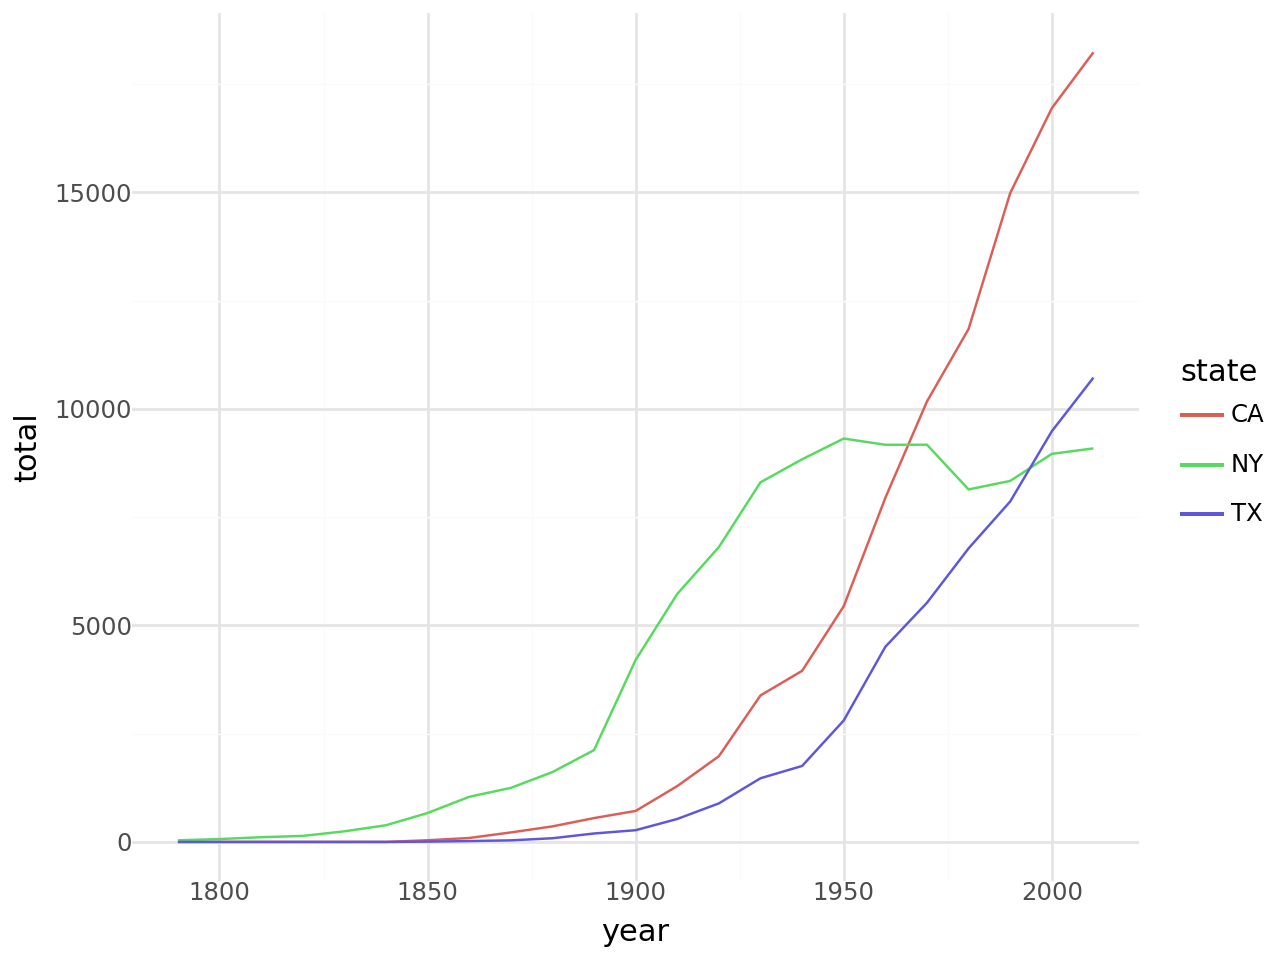

In [18]:
(
    us_pop
    .filter(c.state.is_in(["CA", "TX", "NY"]))
    .group_by(c.state, c.year)
    .agg(total = c.population.sum())
    .ggplot(aes(c.year, c.total, color=c.state))
    .geom_line()
)

13. For the 2010 census, sort by population from largest to smallest, and then use
`.group_by(c.state).head(n=1)` to keep the largest city in each state.

In [19]:
(
    us_pop
    .filter(c.year == 2010)
    .sort(c.population, descending=True)
    .group_by(c.state)
    .head(n=1)
)

state,city,year,population,lon,lat
str,str,i64,f64,f64,f64
"""MN""","""Minneapolis, MN""",2010,382.578,-93.268283,44.963324
"""CT""","""Bridgeport, CT""",2010,144.229,-73.195734,41.187386
"""NH""","""Manchester, NH""",2010,109.565,-71.443893,42.984689
"""TN""","""Memphis, TN""",2010,646.889,-89.978498,35.103543
"""KS""","""Wichita, KS""",2010,382.368,-97.342678,37.690694
…,…,…,…,…,…
"""KY""","""Louisville, KY""",2010,597.337,-85.666708,38.178077
"""NJ""","""Newark, NJ""",2010,277.14,-74.172573,40.72422
"""IN""","""Indianapolis, IN""",2010,820.445,-86.145935,39.776664


14. For the 2010 census, add a column `state_mean` giving the mean population of the
cities in the same state. Use `.over(c.state)`.

In [20]:
(
    us_pop
    .filter(c.year == 2010)
    .with_columns(
        state_mean = c.population.mean().over(c.state)
    )
)

city,state,year,population,lon,lat,state_mean
str,str,i64,f64,f64,f64,f64
"""Anchorage, AK""","""AK""",2010,291.826,-149.274354,61.177549,291.826
"""Birmingham, AL""","""AL""",2010,212.237,-86.799047,33.527444,198.30425
"""Huntsville, AL""","""AL""",2010,180.105,-86.538996,34.784271,198.30425
"""Mobile, AL""","""AL""",2010,195.111,-88.100226,30.668426,198.30425
"""Montgomery, AL""","""AL""",2010,205.764,-86.268593,32.346251,198.30425
…,…,…,…,…,…,…
"""Vancouver, WA""","""WA""",2010,161.791,-122.596517,45.637236,233.857667
"""Green Bay, WI""","""WI""",2010,104.057,-87.984169,44.520676,257.82925
"""Kenosha, WI""","""WI""",2010,99.218,-87.873696,42.58474,257.82925


15. Now compute the same state means with `.group_by` and `.agg`. How is the result
different from the previous question?

In [21]:
(
    us_pop
    .filter(c.year == 2010)
    .group_by(c.state)
    .agg(state_mean = c.population.mean())
)

state,state_mean
str,f64
"""AZ""",401.028333
"""VA""",195.323111
"""RI""",178.042
"""LA""",223.314
"""KS""",190.9742
…,…
"""NJ""",198.97625
"""HI""",387.17
"""ID""",205.671


**Answer**: The .group_by and .agg version returns one row per state, with only the state and its mean. The .over version keeps every city row and writes its state's mean onto each one, so cities in the same state repeat the same value


16. For the 2010 census, keep only the cities whose population is larger than the
mean population of the cities in their own state.

In [22]:
(
    us_pop
    .filter(c.year == 2010)
    .filter(c.population > c.population.mean().over(c.state))
)

city,state,year,population,lon,lat
str,str,i64,f64,f64,f64
"""Birmingham, AL""","""AL""",2010,212.237,-86.799047,33.527444
"""Montgomery, AL""","""AL""",2010,205.764,-86.268593,32.346251
"""Mesa, AZ""","""AZ""",2010,439.041,-111.717379,33.401926
"""Phoenix, AZ""","""AZ""",2010,1445.632,-112.087966,33.572162
"""Tucson, AZ""","""AZ""",2010,520.116,-110.871062,32.154289
…,…,…,…,…,…
"""Norfolk, VA""","""VA""",2010,242.803,-76.244641,36.923015
"""Richmond, VA""","""VA""",2010,204.214,-77.476009,37.531399
"""Virginia Beach, VA""","""VA""",2010,437.994,-76.02402,36.779322


17. For the 2010 census, add a column `rank` giving each city's rank within its state,
with 1 for the largest. Use `c.population.rank(descending=True).over(c.state)`.

In [23]:
(
    us_pop
    .filter(c.year == 2010)
    .with_columns(
        rank = c.population.rank(descending=True).over(c.state)
    )
)

city,state,year,population,lon,lat,rank
str,str,i64,f64,f64,f64,f64
"""Anchorage, AK""","""AK""",2010,291.826,-149.274354,61.177549,1.0
"""Birmingham, AL""","""AL""",2010,212.237,-86.799047,33.527444,1.0
"""Huntsville, AL""","""AL""",2010,180.105,-86.538996,34.784271,4.0
"""Mobile, AL""","""AL""",2010,195.111,-88.100226,30.668426,3.0
"""Montgomery, AL""","""AL""",2010,205.764,-86.268593,32.346251,2.0
…,…,…,…,…,…,…
"""Vancouver, WA""","""WA""",2010,161.791,-122.596517,45.637236,4.0
"""Green Bay, WI""","""WI""",2010,104.057,-87.984169,44.520676,3.0
"""Kenosha, WI""","""WI""",2010,99.218,-87.873696,42.58474,4.0


18. Sort by city and year, add a column `change` equal to
`c.population - c.population.shift(1).over(c.city)`, and filter to Richmond.

In [24]:
(
    us_pop
    .sort(c.city, c.year)
    .with_columns(
        change = c.population - c.population.shift(1).over(c.city)
    )
    .filter(c.city == "Richmond, VA")
)

city,state,year,population,lon,lat,change
str,str,i64,f64,f64,f64,f64
"""Richmond, VA""","""VA""",1790,3.761,-77.476009,37.531399,null
"""Richmond, VA""","""VA""",1800,5.737,-77.476009,37.531399,1.976
"""Richmond, VA""","""VA""",1810,9.735,-77.476009,37.531399,3.998
"""Richmond, VA""","""VA""",1820,12.067,-77.476009,37.531399,2.332
"""Richmond, VA""","""VA""",1830,16.06,-77.476009,37.531399,3.993
…,…,…,…,…,…,…
"""Richmond, VA""","""VA""",1970,249.332,-77.476009,37.531399,29.374
"""Richmond, VA""","""VA""",1980,219.214,-77.476009,37.531399,-30.118
"""Richmond, VA""","""VA""",1990,203.056,-77.476009,37.531399,-16.158


The first row is `null` because there is no census before 1790 to subtract.

19. Take the code from the previous question and draw a bar plot of `change` against
the year with `geom_col`.

/usr/local/lib/python3.13/dist-packages/plotnine/layer.py:344: PlotnineWarning: position_stack : Removed 1 rows containing missing values.


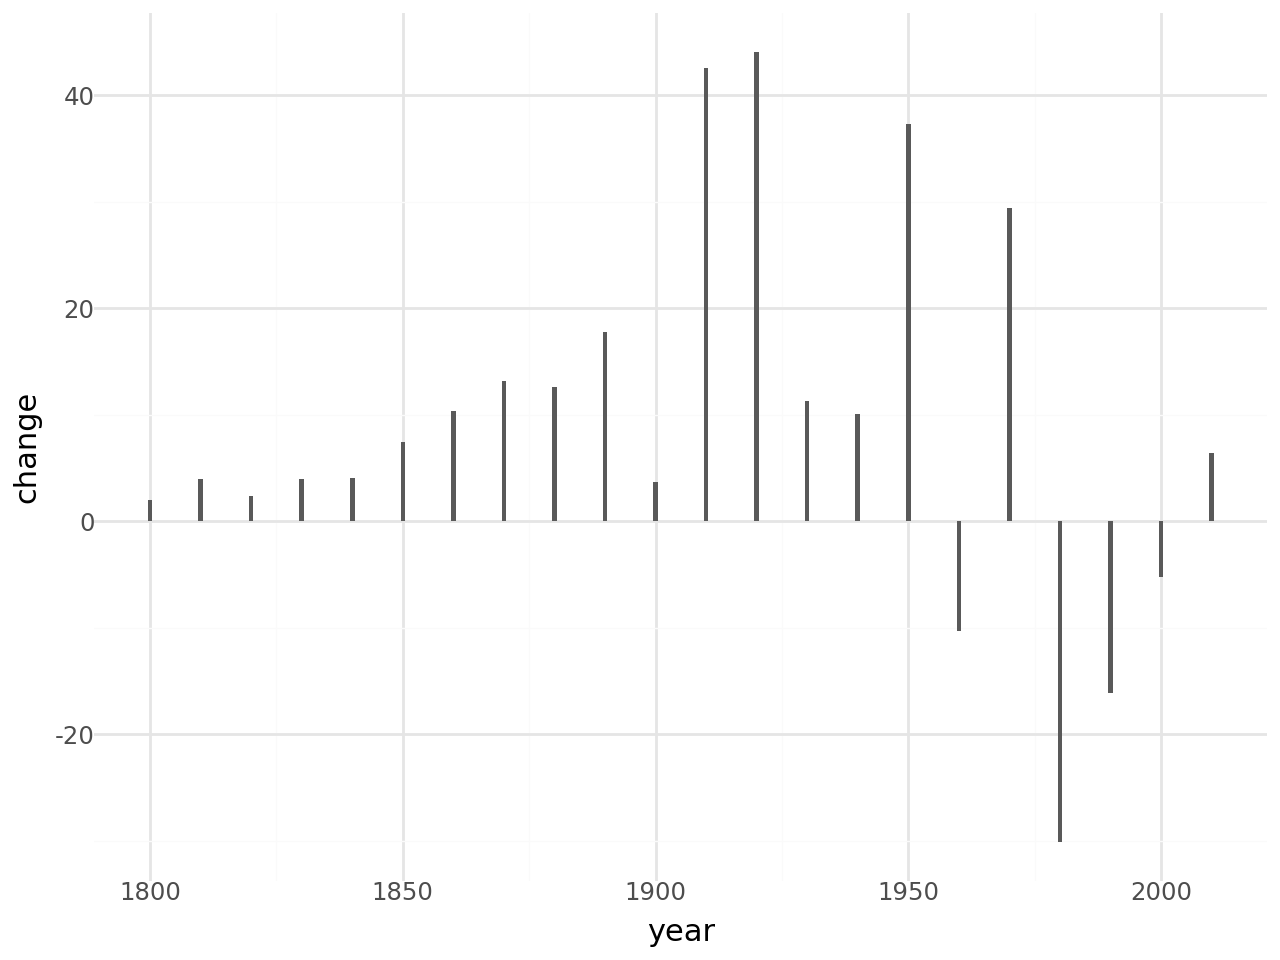

In [26]:
(
    us_pop
    .sort(c.city, c.year)
    .with_columns(
        change = c.population - c.population.shift(1).over(c.city)
    )
    .filter(c.city == "Richmond, VA")
    .ggplot(aes(c.year, c.change))
    .geom_col()
)

Richmond grew in every decade until 1950 and has gone up and down since.

20. For the 2010 census, sort the cities from largest to smallest and add a column
`running` equal to `c.population.cum_sum()`.

In [27]:
(
    us_pop
    .filter(c.year == 2010)
    .sort(c.population, descending=True)
    .with_columns(
        running = c.population.cum_sum()
    )
)

city,state,year,population,lon,lat,running
str,str,i64,f64,f64,f64,f64
"""New York City, NY""","""NY""",2010,8175.133,-73.9385,40.664274,8175.133
"""Los Angeles, CA""","""CA""",2010,3792.621,-118.410825,34.019394,11967.754
"""Chicago, IL""","""IL""",2010,2695.598,-87.681844,41.837551,14663.352
"""Houston, TX""","""TX""",2010,2099.451,-95.386342,29.780472,16762.803
"""Philadelphia, PA""","""PA""",2010,1526.006,-75.133346,40.009375,18288.809
…,…,…,…,…,…,…
"""Sandy, UT""","""UT""",2010,87.461,-111.852286,40.571563,84840.952
"""Nashua, NH""","""NH""",2010,86.494,-71.490544,42.749074,84927.446
"""Duluth, MN""","""MN""",2010,86.265,-92.11871,46.783229,85013.711


Each row adds its population to everything above it, so the sort matters.

21. Sort by city and year and add a column `pop_smooth` equal to
`c.population.rolling_mean(window_size=3).over(c.city)`. Filter to Detroit
(`"Detroit, MI"`). Which rows are missing, and why?

In [28]:
(
    us_pop
    .sort(c.city, c.year)
    .with_columns(
        pop_smooth = c.population.rolling_mean(window_size=3).over(c.city)
    )
    .filter(c.city == "Detroit, MI")
)

city,state,year,population,lon,lat,pop_smooth
str,str,i64,f64,f64,f64,f64
"""Detroit, MI""","""MI""",1790,0.0,-83.102237,42.383038,null
"""Detroit, MI""","""MI""",1800,0.0,-83.102237,42.383038,null
"""Detroit, MI""","""MI""",1810,0.0,-83.102237,42.383038,0.0
"""Detroit, MI""","""MI""",1820,1.4,-83.102237,42.383038,0.466667
"""Detroit, MI""","""MI""",1830,2.2,-83.102237,42.383038,1.2
…,…,…,…,…,…,…
"""Detroit, MI""","""MI""",1970,1514.063,-83.102237,42.383038,1677.925
"""Detroit, MI""","""MI""",1980,1203.368,-83.102237,42.383038,1462.525
"""Detroit, MI""","""MI""",1990,1027.974,-83.102237,42.383038,1248.468333


**Answer**: The first two rows, 1790 and 1800, are missing. Each smoothed value averages a census with the two before it, and Detroit's first two censuses don't have two earlier ones to include


22. Last one. Compute `change` as in question 18, and then, in a second
`.with_columns`, add `change_smooth` equal to
`c.change.rolling_mean(window_size=3).over(c.city)`. Filter to Detroit.

In [29]:
(
    us_pop
    .sort(c.city, c.year)
    .with_columns(
        change = c.population - c.population.shift(1).over(c.city)
    )
    .with_columns(
        change_smooth = c.change.rolling_mean(window_size=3).over(c.city)
    )
    .filter(c.city == "Detroit, MI")
)

city,state,year,population,lon,lat,change,change_smooth
str,str,i64,f64,f64,f64,f64,f64
"""Detroit, MI""","""MI""",1790,0.0,-83.102237,42.383038,null,null
"""Detroit, MI""","""MI""",1800,0.0,-83.102237,42.383038,0.0,null
"""Detroit, MI""","""MI""",1810,0.0,-83.102237,42.383038,0.0,null
"""Detroit, MI""","""MI""",1820,1.4,-83.102237,42.383038,1.4,0.466667
"""Detroit, MI""","""MI""",1830,2.2,-83.102237,42.383038,0.8,0.733333
…,…,…,…,…,…,…,…
"""Detroit, MI""","""MI""",1970,1514.063,-83.102237,42.383038,-156.081,-36.463
"""Detroit, MI""","""MI""",1980,1203.368,-83.102237,42.383038,-310.695,-215.4
"""Detroit, MI""","""MI""",1990,1027.974,-83.102237,42.383038,-175.394,-214.056667


The raw change jumps around: Detroit added 575,000 people in the 1920s and only
55,000 in the 1930s. The smoothed column rises and falls more gradually.